<a href="https://colab.research.google.com/github/ekyaaa/pengolahan-citra/blob/main/Week03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MODUL 3**
Nama : Ekya Muhammad Hasfi Fadlilurrahman <br>
Kelas : TI-3H<br>
NIM : 2341720111

## **D1. Praktikum Operasi Citra Sederhana**

In [2]:
#1&2
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow # for image display
import cv2 as cv
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 50


/tmp/ipython-input-751930627.py:16: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0 ,255)


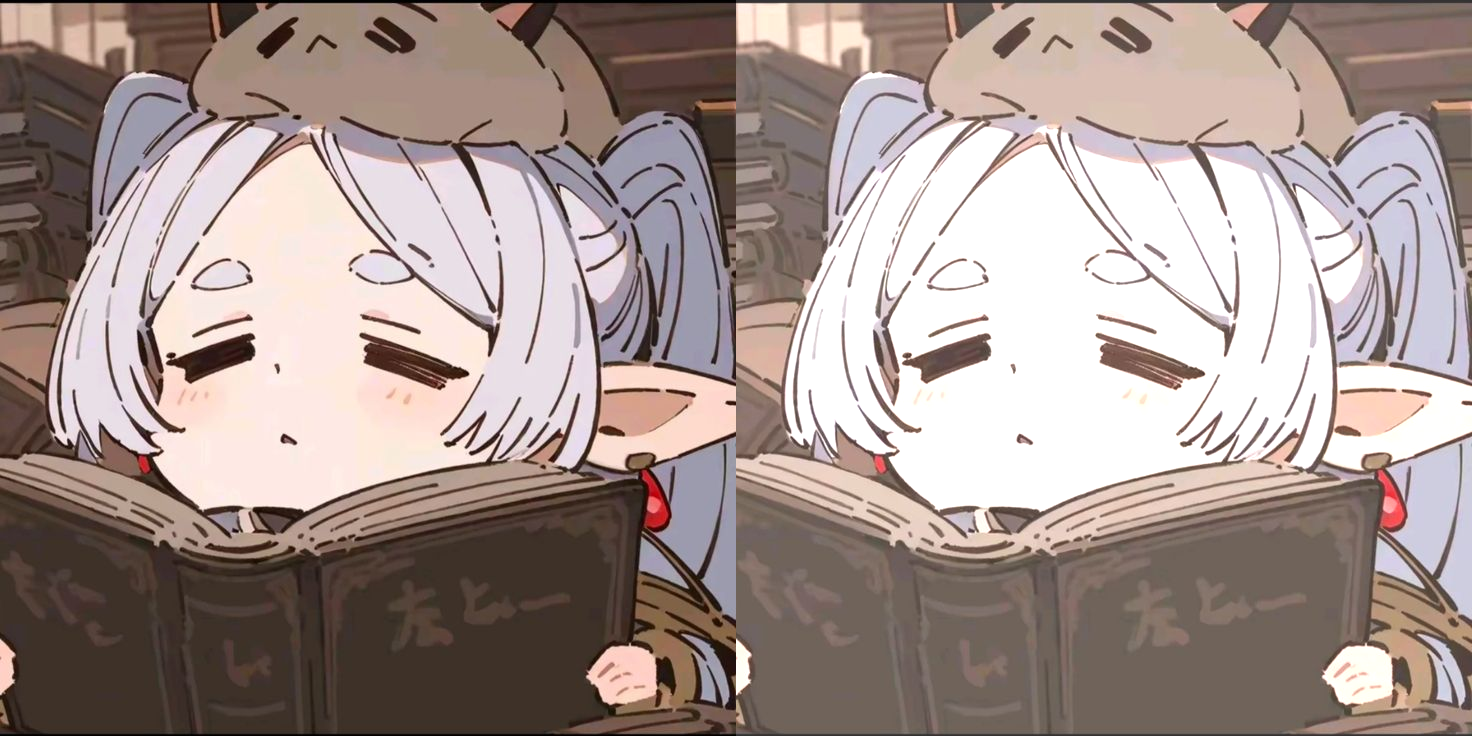

In [3]:
#3
print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/pcvk_images/Frieren.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akse per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
          brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0 ,255)

#cara simpel tanpa for loop
brightness_image = cv.convertScaleAbs(original, beta=brightness)
final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

### **TUGAS PRAKTIKUM D1**

 Mengubah Gambar Menjadi Inverse 
----------------------------------


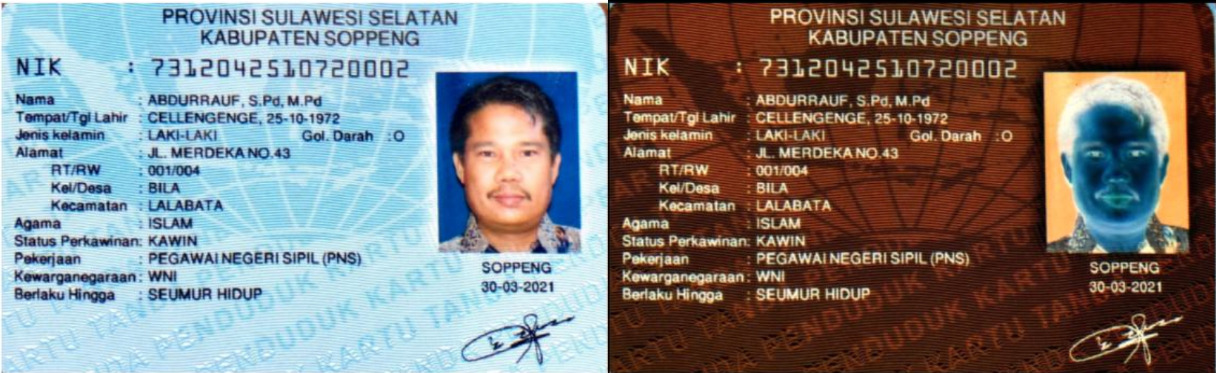

In [4]:
#1
print(' Mengubah Gambar Menjadi Inverse ')
print('----------------------------------')

# baca gambar
original = cv.imread('/content/drive/MyDrive/pcvk_images/week3/ktp_abdurrauf.jpeg')

# inverse
inverse_image = 255 - original

# tampilkan berdampingan
final_frame = cv.hconcat([original, inverse_image])
cv2_imshow(final_frame)

 Mengatur Brightness dan Contrast 
----------------------------------
Masukkan nilai brightness (-255 sampai 255): 50
Masukkan nilai contrast (1.0 sampai 3.0): 2


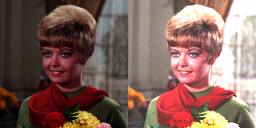

In [5]:
#2
print(' Mengatur Brightness dan Contrast ')
print('----------------------------------')

try:
    brightness = int(input('Masukkan nilai brightness (-255 sampai 255): '))
    contrast = float(input('Masukkan nilai contrast (1.0 sampai 3.0): '))
except ValueError:
    print('Error, input tidak valid')
    brightness = 0
    contrast = 1.0

original = cv.imread('/content/drive/MyDrive/pcvk_images/week3/female.tiff')

adjusted = cv.convertScaleAbs(original, alpha=contrast, beta=brightness)


# Mengatur agar gambar tidak terlalu besar
new_w = int(original.shape[1] * 0.5)
new_h = int(original.shape[0] * 0.5)

original_small = cv.resize(original, (new_w, new_h))
adjusted_small = cv.resize(adjusted, (new_w, new_h))

combined = cv.hconcat([original_small, adjusted_small])

# tampilkan hasil
cv2_imshow(combined)


 Transformasi Log dengan Brightness Dinamis 
----------------------------------
Masukkan nilai brightness (-255 sampai 255): 50


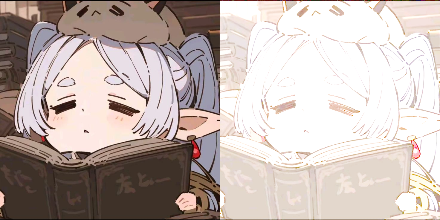

In [6]:
print(' Transformasi Log dengan Brightness Dinamis ')
print('----------------------------------')

try:
    brightness = int(input('Masukkan nilai brightness (-255 sampai 255): '))
except ValueError:
    print('Error, input tidak valid')
    brightness = 0

original = cv.imread('/content/drive/MyDrive/pcvk_images/Frieren.jpg')

img_float = original.astype(np.float32)

c = (255 + brightness) / np.log(1 + np.max(img_float))

log_transformed = c * np.log(1 + img_float)

log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)

# Mengatur agar img bersebelahan dan tidak terlalu besar
new_w = int(original.shape[1] * 0.3)
new_h = int(original.shape[0] * 0.3)

original_small = cv.resize(original, (new_w, new_h))
log_small = cv.resize(log_transformed, (new_w, new_h))

combined = cv.hconcat([original_small, log_small])

cv2_imshow(combined)


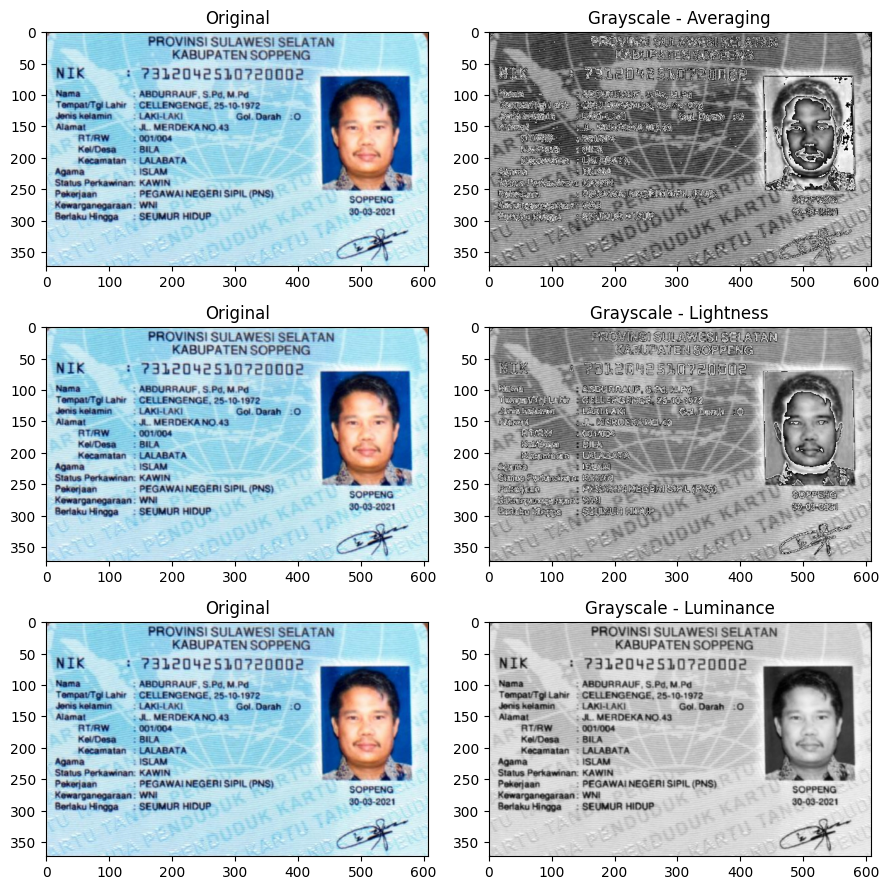

In [7]:
#4

original = cv.imread('/content/drive/MyDrive/pcvk_images/week3/ktp_abdurrauf.jpeg')

img = original.copy()

# Untuk memisahkan warna
B = img[:, :, 0]
G = img[:, :, 1]
R = img[:, :, 2]

# Averaging
gray_avg = ((R + G + B) / 3).astype(np.uint8)

# Lightness
gray_lightness = ((np.maximum(np.maximum(R, G), B) +
                    np.minimum(np.minimum(R, G), B)) / 2).astype(np.uint8)

# Luminance
gray_luminance = (0.299*R + 0.587*G + 0.114*B).astype(np.uint8)

fig, axs = plt.subplots(3, 2, figsize=(9, 9))

# 1. Averaging
axs[0,0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axs[0,0].set_title("Original")
axs[0,0].axis("on")  # tampilkan penggaris

axs[0,1].imshow(gray_avg, cmap="gray")
axs[0,1].set_title("Grayscale - Averaging")
axs[0,1].axis("on")

# 2. Lightness
axs[1,0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axs[1,0].set_title("Original")
axs[1,0].axis("on")

axs[1,1].imshow(gray_lightness, cmap="gray")
axs[1,1].set_title("Grayscale - Lightness")
axs[1,1].axis("on")

# 3. Luminance
axs[2,0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axs[2,0].set_title("Original")
axs[2,0].axis("on")

axs[2,1].imshow(gray_luminance, cmap="gray")
axs[2,1].set_title("Grayscale - Luminance")
axs[2,1].axis("on")

plt.tight_layout()
plt.show()



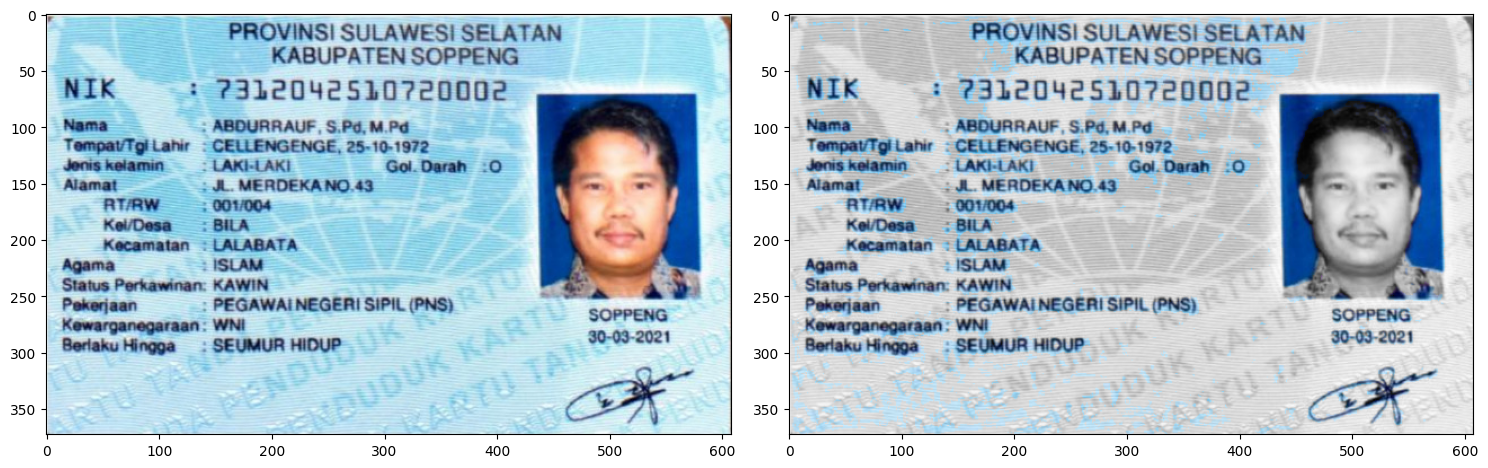

In [8]:
# 5
img = cv.imread('/content/drive/MyDrive/pcvk_images/week3/ktp_abdurrauf.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Konversi ke HSV
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Tentukan rentang warna biru (hue sekitar 100–140)
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([140, 255, 255])

# Buat mask untuk biru
mask = cv.inRange(hsv, lower_blue, upper_blue)

# Buat citra grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_rgb = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)  # ubah jadi 3 channel

result = np.where(mask[:, :, None] == 255, img_rgb, gray_rgb)

# Tampilkan hasil
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].imshow(img_rgb)
axs[0].axis("on")

axs[1].imshow(result)
axs[1].axis("on")

plt.tight_layout()
plt.show()


## **D2. Operasi Aritmatika dan Logika**

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


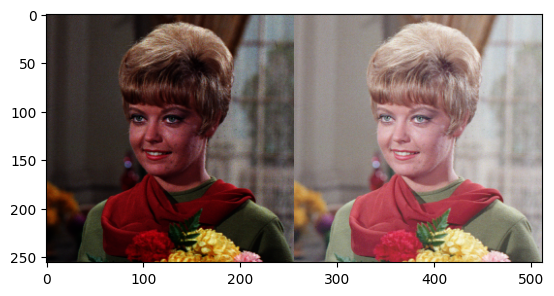

In [9]:

# 1.

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
  gamma = int(input('Masukkan nilai Gamma: '))
except ValueError:
  print('Error, not a number')

img_female = cv.imread('/content/drive/MyDrive/pcvk_images/week3/female.tiff')
img = cv.cvtColor(img_female, cv.COLOR_BGR2RGB)

normalized = img / 255.0

# Terapkan gamma correction sesuai rumus: I' = 255 * (I/255)^(1/gamma)
gamma_corrected = 255 * (normalized ** (1.0 / gamma))

# Pastikan ke rentang [0,255] dan ubah ke uint8
gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

# Gabungkan untuk perbandingan
gamma_frame = cv.hconcat((img, gamma_corrected))
plt.imshow(gamma_frame)



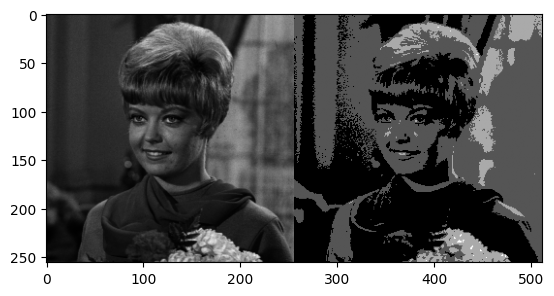

In [10]:
# 2.

bit_depth=2
level = 255 / (pow(2,bit_depth)-1)

original = cv.imread('/content/drive/MyDrive/pcvk_images/week3/female.tiff', cv.IMREAD_GRAYSCALE)

# Proses kuantisasi
quant = np.round(original / level) * level
quant = np.clip(quant, 0, 255).astype(np.uint8)

quant_frame = cv.hconcat((original, quant))
plt.imshow(quant_frame, cmap='gray')



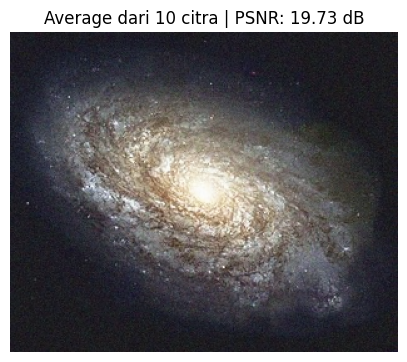

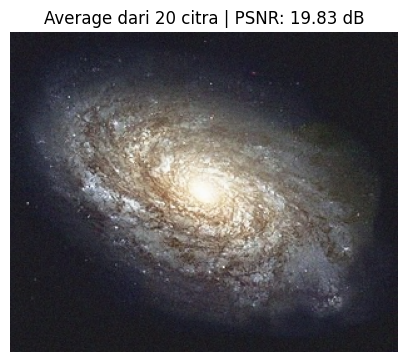

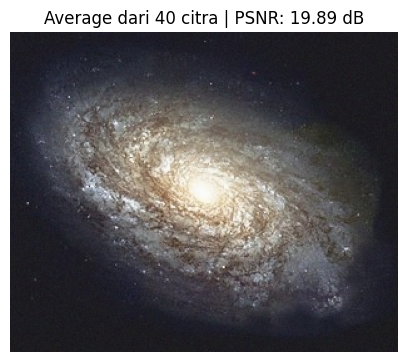

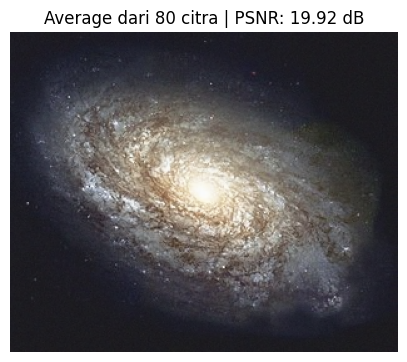

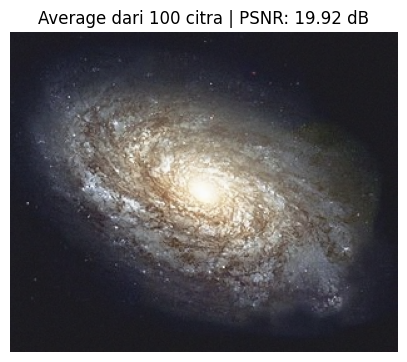

Hasil PSNR: {10: 19.728620302173795, 20: 19.834295165070067, 40: 19.88847310972901, 80: 19.917908127777633, 100: 19.921960894415548}


In [11]:
# 3.


import glob
from math import log10

def psnr(img1, img2):
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 10 * log10((PIXEL_MAX ** 2) / mse)

original = cv.imread('/content/drive/MyDrive/pcvk_images/Images/galaxy.jpg')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)

cv_img = []
for img in glob.glob('/content/drive/MyDrive/pcvk_images/Images/noises/*.jpg'):
    n = cv.imread(img)
    n = cv.cvtColor(n, cv.COLOR_BGR2RGB)
    cv_img.append(n)

test_counts = [10, 20, 40, 80, 100]
psnr_values = []
for count in test_counts:
    avg_img = np.mean(cv_img[:count], axis=0).astype(np.uint8)

    value = psnr(original, avg_img)
    psnr_values.append(value)

    plt.figure(figsize=(5,5))
    plt.imshow(avg_img)
    plt.title(f"Average dari {count} citra | PSNR: {value:.2f} dB")
    plt.axis("off")
    plt.show()

print("Hasil PSNR:", dict(zip(test_counts, psnr_values)))



Ketika jumlah citra noisy yang dirata-rata bertambah, hasil citra semakin halus dan citra semakin mirip citra asli.

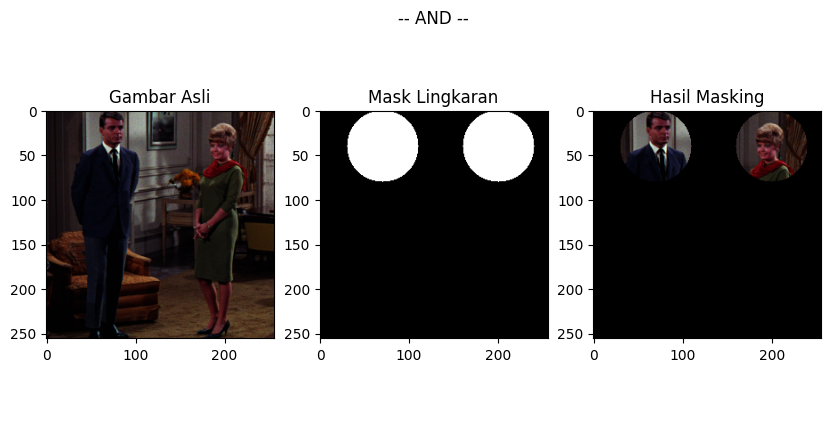

In [12]:
# 4.

img = cv.imread('/content/drive/MyDrive/pcvk_images/Images/couple.tiff')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

mask = np.zeros(img.shape[:2], dtype=np.uint8)

circles = [(70, 40, 40), (200, 40, 40)]

for (x, y, r) in circles:
    cv.circle(mask, (x, y), r, 255, -1)

masked_img = cv.bitwise_and(img, img, mask=mask)

plt.figure(figsize=(10,5))

plt.title("-- AND --")
plt.axis("off")

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Gambar Asli")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask Lingkaran")

plt.subplot(1,3,3)
plt.imshow(masked_img)
plt.title("Hasil Masking")

plt.show()

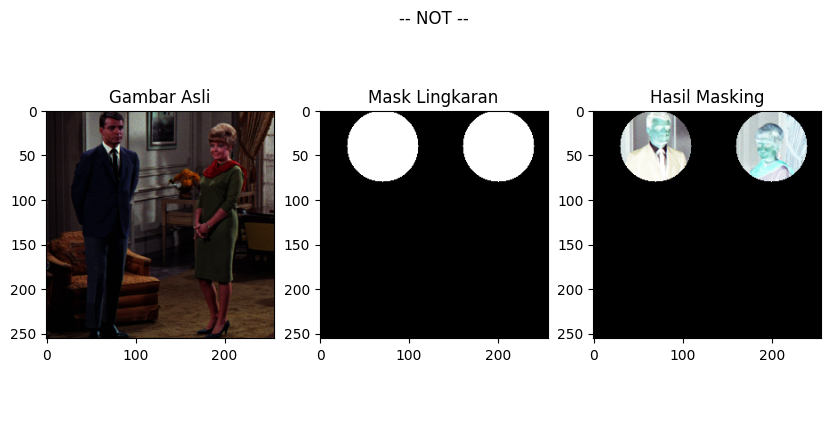

In [13]:
img = cv.imread('/content/drive/MyDrive/pcvk_images/Images/couple.tiff')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

mask = np.zeros(img.shape[:2], dtype=np.uint8)

circles = [(70, 40, 40), (200, 40, 40)]

for (x, y, r) in circles:
    cv.circle(mask, (x, y), r, 255, -1)

masked_img = cv.bitwise_not(img, mask=mask)

plt.figure(figsize=(10,5))

plt.title("-- NOT --")
plt.axis("off")

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Gambar Asli")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask Lingkaran")

plt.subplot(1,3,3)
plt.imshow(masked_img)
plt.title("Hasil Masking")

plt.show()

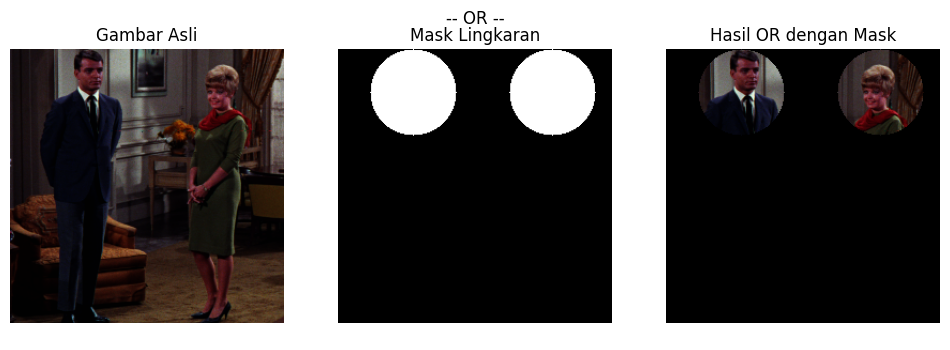

In [14]:
for (x, y, r) in circles:
    cv.circle(mask, (x, y), r, 255, -1)

or_img = cv.bitwise_or(img, img, mask=mask)

plt.figure(figsize=(12,4))

plt.title("-- OR --")
plt.axis("off")

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask Lingkaran")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(or_img)
plt.title("Hasil OR dengan Mask")
plt.axis("off")

plt.show()

In [ ]:
masked_img = cv.bitwise_and(img, img, mask=mask)

plt.figure(figsize=(10,5))

plt.title("-- AND --")
plt.axis("off")

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Gambar Asli")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask Lingkaran")

plt.subplot(1,3,3)
plt.imshow(masked_img)
plt.title("Hasil Masking")

plt.show()

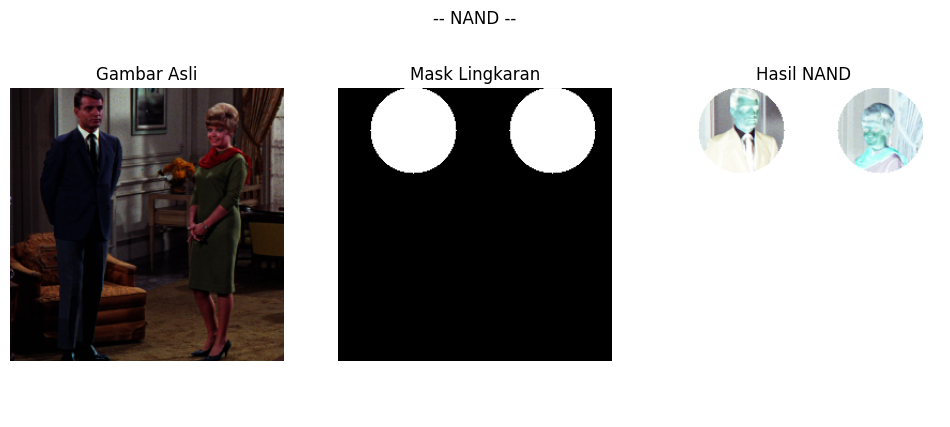

In [15]:
# Terapkan operator AND
and_img = cv.bitwise_and(img, img, mask=mask)

nand_img = cv.bitwise_not(and_img)

plt.figure(figsize=(12,5))

plt.title("-- NAND --")
plt.axis("off")

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask Lingkaran")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(nand_img)
plt.title("Hasil NAND")
plt.axis("off")

plt.show()